# Fake67: Explainable Deepfake Audio Detection via Spectrograms Using EfficientNet-B4 and GradCAM - Training Notebook Scaffold (Training & Tuning)

This notebook scaffolds Phase 3 environment setup and the Q3 VRAM gate for EfficientNet-B4.

Training loop itself is intentionally deferred to later chains

## Clone Project Repository

In [2]:
!git clone https://github.com/ibrahimferel/final-fried-kcv.git
%cd /content/final-fried-kcv


## Env & URL Repository

In [3]:
import os
os.environ["DSDBA_REPO_URL"] = "https://github.com/ibrahimferel/final-fried-kcv.git"

## Mount Drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

## Install Required Dependencies

In [7]:
!pip install torch torchvision torchaudio librosa numpy gradio grad-cam onnxruntime pydantic datasets huggingface-hub

## Setup Python Path and Working Directory

In [9]:
import sys
sys.path.append("/content/final-fried-kcv")

from pathlib import Path
import os

os.chdir("/content/final-fried-kcv")
print("Working dir:", Path.cwd())

## Load Configuration and Setup Drive Paths

In [10]:
from pathlib import Path
import yaml

cfg_path = Path("/content/final-fried-kcv/config.yaml")
cfg = yaml.safe_load(cfg_path.read_text())

# Drive roots (edit only these values if needed)
DATASET_ROOT = "/content/drive/MyDrive/dsdba-fix/dataset"
PREPROCESSED_ROOT = "/content/drive/MyDrive/dsdba-fix/preprocessed"
CHECKPOINT_ROOT = "/content/drive/MyDrive/dsdba-fix/models/checkpoints"
BEST_CHECKPOINT_FILENAME = "best_model.pth"
RESUME_CHECKPOINT = "/content/drive/MyDrive/dsdba-fix/models/checkpoints/best_models.pth"

cfg["training"]["dataset_root"] = DATASET_ROOT
cfg["training"]["preprocessed_root"] = PREPROCESSED_ROOT
cfg["training"]["checkpoint_root"] = CHECKPOINT_ROOT
cfg["training"]["best_checkpoint_filename"] = BEST_CHECKPOINT_FILENAME
cfg["training"]["resume_checkpoint"] = RESUME_CHECKPOINT


## Audio DSP: symlink dataset + cache `.pt` di Drive


In [ ]:
import os
from pathlib import Path

DATASET_ROOT = "/content/drive/MyDrive/dsdba-fix/dataset"

DRIVE_ROOT = "/content/drive/MyDrive/dsdba-fix"
PREPROCESSED_ROOT = f"{DRIVE_ROOT}/preprocessed"
CACHE_ROOT = PREPROCESSED_ROOT
MODEL_ROOT = f"{DRIVE_ROOT}/models"
EXPERIMENT_ROOT = f"{DRIVE_ROOT}/experiments"

REPO_ROOT = "/content/final-fried-kcv"

HF_REPO_ID = "safamashita/dsdba-efficientnet-b4"


### Link Dataset and Verify Data Structure

In [ ]:
splits = {'training': 'train', 'validation': 'validation', 'testing': 'test'}
labels = {'fake': 'spoof', 'real': 'bonafide'}

for src_split, dst_split in splits.items():
    for src_label, dst_label in labels.items():
        src_path = f'{DATASET_ROOT}/{src_split}/{src_label}'
        dst_path = f'{REPO_ROOT}/data/{dst_split}/{dst_label}'
        os.makedirs(os.path.dirname(dst_path), exist_ok=True)
        if not os.path.exists(dst_path):
            os.symlink(src_path, dst_path)
            print(f'✅ Linked: {src_path} → {dst_path}')
        else:
            print(f'⏭️  Already linked: {dst_path}')

print('\nVerifikasi jumlah file:')
for split in ['train', 'validation', 'test']:
    for label in ['bonafide', 'spoof']:
        path = f'{REPO_ROOT}/data/{split}/{label}'
        if os.path.exists(path):
            count = len(os.listdir(path))
            print(f'  {split}/{label}: {count} files')
        else:
            print(f'  ❌ Missing: {split}/{label}')

### Audio DSP Processing and Spectrogram Caching

In [ ]:
import sys, torch, yaml
sys.path.insert(0, REPO_ROOT)
from src.audio.dsp import preprocess_audio

with open(f'{REPO_ROOT}/config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

print('🎵 Memulai Audio DSP Cache...')
print(f'   Output → {CACHE_ROOT}  (permanen di Drive)\n')

total_processed = 0
total_skipped   = 0

for split in ['train', 'validation']:
    for label in ['bonafide', 'spoof']:
        src_dir = f'{REPO_ROOT}/data/{split}/{label}'
        dst_dir = f'{CACHE_ROOT}/{split}/{label}'   # ← Drive, bukan /content
        os.makedirs(dst_dir, exist_ok=True)

        files = list(Path(src_dir).glob('*.wav')) + list(Path(src_dir).glob('*.flac'))
        print(f'Processing {split}/{label}: {len(files)} files')

        for i, f_path in enumerate(files):
            out = Path(dst_dir) / (f_path.stem + '.pt')

            if out.exists():                         # ← sudah di Drive? skip!
                total_skipped += 1
                if i % 500 == 0:
                    print(f'  ⏭️  {i}/{len(files)} (skip — sudah ada di Drive)')
                continue

            tensor = preprocess_audio(f_path, cfg)
            torch.save(tensor, out)
            total_processed += 1

            if i % 500 == 0:
                print(f'  ✅ {i}/{len(files)} done...')

print(f'\n✅ Cache selesai!')
print(f'   Diproses : {total_processed} files')
print(f'   Di-skip  : {total_skipped} files (sudah ada di Drive)')

## Model Training and Fine-Tuning Pipeline (EfficientNet-B4)

In [ ]:
import os
import sys
import time
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import yaml
from torch.utils.data import DataLoader, Dataset

sys.path.insert(0, '/content/final-fried-kcv')

from src.cv.model import DSDBAModel
from src.cv.train import (
    compute_eer,
    get_class_weights,
    build_augmentations,
    train_epoch,
    validate_epoch,
)
from sklearn.metrics import roc_auc_score

cfg = yaml.safe_load(Path('/content/final-fried-kcv/config.yaml').read_text())

# resume mode
RESUME_PHASE2 = True
RESUME_BEST_AUC = 0.927230   # AUC terbaik saat crash, update jika berbeda

# hyperparams
PHASE1_EPOCHS = 5
PHASE2_EPOCHS = 15
PHASE1_LR = 1e-3
PHASE2_LR = 5e-5
UNFREEZE_BLOCKS = 3
PATIENCE = 5
BATCH_SIZE = int(cfg['training'].get('batch_size', 16))
NUM_WORKERS = 2
USE_AMP = True

# paths
pre_root = Path(cfg['training']['preprocessed_root'])
ckpt_dir = Path(cfg['training']['checkpoint_root'])
ckpt_dir.mkdir(parents=True, exist_ok=True)
best_ckpt = ckpt_dir / cfg['training']['best_checkpoint_filename']

# dataset: load preprocessed .pt
class PreprocessedDataset(Dataset):
    def __init__(self, root: Path, transform=None):
        self.items = []
        self.labels = []
        self.transform = transform
        for label_name, y in (('bonafide', 0), ('spoof', 1)):
            d = root / label_name
            if not d.is_dir():
                raise FileNotFoundError(f'Folder tidak ada: {d}')
            for p in sorted(d.glob('*.pt')):
                self.items.append(p)
                self.labels.append(y)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        t = torch.load(self.items[idx], map_location='cpu')
        if t.ndim == 4:
            t = t.squeeze(0)
        t = t.to(dtype=torch.float32)
        if self.transform is not None:
            t = self.transform(t)
        return t, int(self.labels[idx])

augment_fn = build_augmentations(cfg)

train_dataset = PreprocessedDataset(pre_root / 'train', transform=augment_fn)
val_dataset   = PreprocessedDataset(pre_root / 'validation', transform=None)

print(f'Train: {len(train_dataset)} (bonafide={sum(1 for y in train_dataset.labels if y==0)}, spoof={sum(1 for y in train_dataset.labels if y==1)})')
print(f'Val:   {len(val_dataset)} (bonafide={sum(1 for y in val_dataset.labels if y==0)}, spoof={sum(1 for y in val_dataset.labels if y==1)})')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# model + loss
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DSDBAModel(cfg=cfg, pretrained=True).to(device)

class_weights = get_class_weights(train_dataset).to(device)
print(f'Class weights [bonafide, spoof]: {class_weights.tolist()}')
criterion = nn.CrossEntropyLoss(weight=class_weights)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and device.type == 'cuda')

if RESUME_PHASE2:
    # skip fase 1, load checkpoint langsung
    assert best_ckpt.exists(), f'Checkpoint tidak ditemukan: {best_ckpt}'
    model.load_state_dict(torch.load(str(best_ckpt), map_location=device))
    best_auc = RESUME_BEST_AUC
    print(f'\n⏩ RESUME MODE: Fase 1 di-skip.')
    print(f'   Loaded checkpoint: {best_ckpt}')
    print(f'   Melanjutkan dari best AUC={best_auc:.6f}')
else:
    # fase 1: head-only
    model.freeze_backbone()
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=PHASE1_LR,
        weight_decay=1e-2,
    )

    best_auc = -math.inf
    no_improve = 0

    print(f'\n=== Fase 1: Head-only ({PHASE1_EPOCHS} epochs, lr={PHASE1_LR}) ===')
    for epoch in range(1, PHASE1_EPOCHS + 1):
        t0 = time.time()
        train_m = train_epoch(model, train_loader, optimizer, criterion, cfg, scaler=scaler)
        val_m = validate_epoch(model, val_loader, cfg)
        elapsed = time.time() - t0
        auc = val_m['auc_roc']
        eer = val_m['eer']
        loss = train_m['train_loss']
        acc = train_m['train_acc']
        print(f'  Epoch {epoch}/{PHASE1_EPOCHS} | loss={loss:.4f} acc={acc:.4f} | AUC={auc:.4f} EER={eer:.4f} | {elapsed:.1f}s')
        if auc > best_auc:
            best_auc = auc
            torch.save(model.state_dict(), str(best_ckpt))
            print(f'    Best model (AUC={best_auc:.6f}) saved → {best_ckpt}')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'    Early stop (patience={PATIENCE})')
                break

# fase 2: unfreeze top blok
model.load_state_dict(torch.load(str(best_ckpt), map_location=device))
model.unfreeze_top_n(n=UNFREEZE_BLOCKS)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=PHASE2_LR,
    weight_decay=1e-2,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE2_EPOCHS, eta_min=1e-6)

no_improve = 0
print(f'\n=== Fase 2: Fine-tune top-{UNFREEZE_BLOCKS} blok ({PHASE2_EPOCHS} epochs, lr={PHASE2_LR}) ===')
for epoch in range(1, PHASE2_EPOCHS + 1):
    t0 = time.time()
    train_m = train_epoch(model, train_loader, optimizer, criterion, cfg, scaler=scaler)
    val_m = validate_epoch(model, val_loader, cfg)
    scheduler.step()
    elapsed = time.time() - t0
    auc = val_m['auc_roc']
    eer = val_m['eer']
    loss = train_m['train_loss']
    acc = train_m['train_acc']
    current_lr = optimizer.param_groups[0]['lr']
    print(f'  Epoch {epoch}/{PHASE2_EPOCHS} | loss={loss:.4f} acc={acc:.4f} | AUC={auc:.4f} EER={eer:.4f} | lr={current_lr:.2e} | {elapsed:.1f}s')
    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), str(best_ckpt))
        print(f'    Best model (AUC={best_auc:.6f}) saved → {best_ckpt}')
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'    Early stop (patience={PATIENCE})')
            break

model.load_state_dict(torch.load(str(best_ckpt), map_location=device))
model.eval()
print(f'\n🎉 Fine-tune selesai! Best AUC-ROC (val): {best_auc:.6f}')
print(f'Checkpoint: {best_ckpt}')
print('\nLanjut: jalankan Cell 8 (load checkpoint) → Cell 9 (evaluasi test).')


## Export Model to ONNX and Verify Equivalence

In [ ]:
from src.cv.infer import export_to_onnx, verify_onnx_equivalence
import shutil

assert "model" in globals() and "cfg" in globals(), "Jalankan Cell 8 dulu (load checkpoint)."

model.eval()
print(f"Model loaded, exporting to ONNX...")

onnx_path = export_to_onnx(model, cfg)
print(f"ONNX saved: {onnx_path}")

ok = verify_onnx_equivalence(model, onnx_path, cfg)
print(f"ONNX equivalence: {ok}")
assert ok, "ONNX equivalence check failed! |diff| >= tolerance."

ckpt_dir = Path(cfg["training"]["checkpoint_root"])
onnx_drive = ckpt_dir / "dsdba_efficientnet_b4.onnx"
shutil.copy(onnx_path, str(onnx_drive))
print(f"Model ONNX tersimpan di Drive: {onnx_drive}")

## Authenticate with Hugging Face Hub

In [ ]:
import os
from huggingface_hub import login

HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        HF_TOKEN = None

assert HF_TOKEN, "Missing HF_TOKEN. Set Runtime → Secrets (name: HF_TOKEN) in Colab, or export HF_TOKEN."

login(token=HF_TOKEN)
print("Hugging Face login OK.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Hugging Face login OK.


## Create Model Repository on Hugging Face

In [ ]:
from huggingface_hub import HfApi

api = HfApi()

api.create_repo(
    repo_id="safamashita/dsdba-efficientnet-b4",
    repo_type="model",
    private=False,
    exist_ok=True
)

RepoUrl('https://huggingface.co/ibrahimferel/dsdba-efficientnet-b4', endpoint='https://huggingface.co', repo_type='model', repo_id='ibrahimferel/dsdba-efficientnet-b4')

## Upload Model Artifacts to Hugging Face

In [ ]:
from huggingface_hub import HfApi

api = HfApi()

# upload checkpoint PyTorch
api.upload_file(
    path_or_fileobj="/content/drive/MyDrive/dsdba-fix/models/checkpoints/best_model.pth",
    path_in_repo="best_model.pth",                   # nama di repo HF
    repo_id="safamashita/dsdba-efficientnet-b4",
    repo_type="model",
    commit_message="Upload best model checkpoint - AUC 0.9726"
)

api.upload_file(
    path_or_fileobj="/content/drive/MyDrive/dsdba-fix/models/checkpoints/dsdba_efficientnet_b4.onnx",
    path_in_repo="model.onnx",
    repo_id="safamashita/dsdba-efficientnet-b4",
    repo_type="model",
    commit_message="Upload ONNX model for CPU inference"
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...heckpoints/best_model.pth: 100%|##########| 71.0MB / 71.0MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...sdba_efficientnet_b4.onnx:  10%|#         | 7.13MB / 70.1MB            

CommitInfo(commit_url='https://huggingface.co/ibrahimferel/dsdba-efficientnet-b4/commit/08c48da1635313c46a823abf644d2a12c738e292', commit_message='Upload ONNX model for CPU inference', commit_description='', oid='08c48da1635313c46a823abf644d2a12c738e292', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ibrahimferel/dsdba-efficientnet-b4', endpoint='https://huggingface.co', repo_type='model', repo_id='ibrahimferel/dsdba-efficientnet-b4'), pr_revision=None, pr_num=None)

## Load Best Model Checkpoint for Evaluation

In [12]:
from pathlib import Path
import torch
import yaml

from src.cv.model import DSDBAModel

cfg = yaml.safe_load(Path("config.yaml").read_text())
ckpt_dir = Path(cfg["training"]["checkpoint_root"])
best_ckpt = ckpt_dir / cfg["training"]["best_checkpoint_filename"]

assert best_ckpt.exists(), f"Best checkpoint not found: {best_ckpt}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DSDBAModel(cfg=cfg, pretrained=False).to(device)

state = torch.load(best_ckpt, map_location=device)

model.load_state_dict(state)

model.eval()

print("Loaded best checkpoint:", best_ckpt)
print("Total parameters loaded:", len(state))



## Model Evaluation on Test Set (AUC, EER, and Threshold Analysis)

In [13]:
from pathlib import Path
import csv
import torch
import yaml
import numpy as np

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **k: x

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from IPython.display import Markdown, display
from PIL import Image

from src.cv.gradcam import run_gradcam
from src.cv.train import compute_eer

cfg = yaml.safe_load(Path("config.yaml").read_text())
pre_root = Path(cfg["training"]["preprocessed_root"]) / "test"
threshold = float(cfg["model"].get("decision_threshold", 0.5))


EVAL_MAX_FILES = None
BATCH_SIZE = int(cfg["training"].get("batch_size", 16))
SAVE_PREDICTIONS_CSV = True
NUM_GRADCAM_SAMPLES = 0


def _load_pt(path: Path) -> torch.Tensor:
    t = torch.load(path, map_location="cpu")
    if t.ndim == 4:
        t = t.squeeze(0)
    return t.to(dtype=torch.float32)


def _collect_items() -> list[tuple[Path, int]]:
    out: list[tuple[Path, int]] = []
    for label_name, y in (("bonafide", 0), ("spoof", 1)):
        d = pre_root / label_name
        if not d.is_dir():
            raise FileNotFoundError(f"Folder tidak ada: {d}")
        for p in sorted(d.glob("*.pt")):
            out.append((p, y))
    return out


assert "model" in globals() and "device" in globals(), "Jalankan Cell 8 dulu (load checkpoint)."

items = _collect_items()
if not items:
    raise RuntimeError(f"Tidak ada file .pt di bawah {pre_root}")

if EVAL_MAX_FILES is not None:
    items = items[: int(EVAL_MAX_FILES)]

n_b = sum(1 for _, y in items if y == 0)
n_s = sum(1 for _, y in items if y == 1)
display(Markdown(
    f"**Evaluasi test** — `{pre_root}`  \n"
    f"Total **{len(items)}** file .pt (bonafide={n_b}, spoof={n_s})"
))

y_true: list[int] = []
y_score_spoof: list[float] = []
y_pred_argmax: list[int] = []
y_pred_thresh: list[int] = []
rows_out: list[dict[str, object]] = []

n_batches = (len(items) + BATCH_SIZE - 1) // BATCH_SIZE
for bi in tqdm(range(n_batches), desc="Inference"):
    chunk = items[bi * BATCH_SIZE : (bi + 1) * BATCH_SIZE]
    batch = torch.stack([_load_pt(p) for p, _ in chunk]).to(device)
    with torch.no_grad():
        logits = model(batch)
    scores = torch.sigmoid(logits[:, 1]).detach().cpu().numpy()
    pred_arg = torch.argmax(logits, dim=1).detach().cpu().numpy()
    pred_thr = (scores >= threshold).astype(np.int64)

    for j, (path, y) in enumerate(chunk):
        sc = float(scores[j])
        pa = int(pred_arg[j])
        pt = int(pred_thr[j])
        y_true.append(y)
        y_score_spoof.append(sc)
        y_pred_argmax.append(pa)
        y_pred_thresh.append(pt)
        rows_out.append(
            {
                "path": str(path),
                "y_true": y,
                "pred_argmax": pa,
                "pred_threshold": pt,
                "score_spoof_sigmoid": sc,
            }
        )

y_true_arr = np.asarray(y_true, dtype=np.int64)
y_score_arr = np.asarray(y_score_spoof, dtype=np.float64)

try:
    auc = float(roc_auc_score(y_true_arr, y_score_arr))
except ValueError as e:
    auc = float("nan")
    print("AUC tidak terhitung:", e)
eer = float(compute_eer(y_true_arr.tolist(), y_score_arr.tolist()))

from sklearn.metrics import roc_curve as _roc_curve
_fpr_t, _tpr_t, _thr_t = _roc_curve(y_true_arr, y_score_arr, pos_label=1)
_fnr_t = 1.0 - _tpr_t
_idx_eer_t = int(np.nanargmin(np.abs(_fnr_t - _fpr_t)))
threshold_eer_test = float(_thr_t[_idx_eer_t])

labels_order = [0, 1]
target_names = ["bonafide", "spoof"]

cm_arg = confusion_matrix(y_true_arr, np.asarray(y_pred_argmax), labels=labels_order)
cm_thr = confusion_matrix(y_true_arr, np.asarray(y_pred_thresh), labels=labels_order)

print("\n=== AUC-ROC (skor = sigmoid logit spoof) ===")
print(f"AUC-ROC: {auc:.6f}")
print(f"EER:     {eer:.6f}")
print(f"Threshold keputusan (cfg): {threshold}")
print(f"EER threshold (test set):  {threshold_eer_test:.6f}")

print("\n=== Confusion matrix — prediksi = argmax(logits) [disarankan vs CE] ===")
print("Rows: y_true, Cols: y_pred")
print(cm_arg)
print(classification_report(y_true_arr, y_pred_argmax, labels=[0, 1], target_names=target_names, digits=4, zero_division=0))

print("\n=== Confusion matrix — prediksi = (score_spoof >= threshold) [seperti infer.py] ===")
print(cm_thr)
print(classification_report(y_true_arr, y_pred_thresh, labels=[0, 1], target_names=target_names, digits=4, zero_division=0))

y_pred_eer_t = (y_score_arr >= threshold_eer_test).astype(np.int64)
cm_eer_t = confusion_matrix(y_true_arr, y_pred_eer_t, labels=labels_order)
print(f"\n=== Confusion matrix — EER threshold test ({threshold_eer_test:.6f}) ===")
print(cm_eer_t)
print(classification_report(y_true_arr, y_pred_eer_t, labels=[0, 1], target_names=target_names, digits=4, zero_division=0))

if SAVE_PREDICTIONS_CSV:
    csv_path = pre_root / "eval_test_predictions.csv"
    with csv_path.open("w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=list(rows_out[0].keys()))
        w.writeheader()
        w.writerows(rows_out)
    print(f"\nCSV prediksi tersimpan: {csv_path}")

if NUM_GRADCAM_SAMPLES > 0:
    print("\n--- Grad-CAM (opsional, sampel pertama) ---")
    for pt_path, y_lbl in items[:NUM_GRADCAM_SAMPLES]:
        tensor = _load_pt(pt_path)
        x = tensor.unsqueeze(0).to(device)
        heatmap_path, band_attr = run_gradcam(tensor=x, model=model, cfg=cfg)
        print(pt_path.name, "expected_label=", y_lbl, "heatmap=", heatmap_path, "bands=", band_attr)
        display(Image.open(heatmap_path))



**Evaluasi test** — `/content/drive/MyDrive/dsdba-fix/preprocessed/test`  
Total **1088** file .pt (bonafide=544, spoof=544)

Inference:   0%|          | 0/68 [00:00<?, ?it/s]


=== AUC-ROC (skor = sigmoid logit spoof) ===
AUC-ROC: 0.936429
EER:     0.139706
Threshold keputusan (cfg): 0.93
EER threshold (test set):  0.930040

=== Confusion matrix — prediksi = argmax(logits) [disarankan vs CE] ===
Rows: y_true, Cols: y_pred
[[113 431]
 [  0 544]]
              precision    recall  f1-score   support

    bonafide     1.0000    0.2077    0.3440       544
       spoof     0.5579    1.0000    0.7163       544

    accuracy                         0.6039      1088
   macro avg     0.7790    0.6039    0.5301      1088
weighted avg     0.7790    0.6039    0.5301      1088


=== Confusion matrix — prediksi = (score_spoof >= threshold) [seperti infer.py] ===
[[468  76]
 [ 76 468]]
              precision    recall  f1-score   support

    bonafide     0.8603    0.8603    0.8603       544
       spoof     0.8603    0.8603    0.8603       544

    accuracy                         0.8603      1088
   macro avg     0.8603    0.8603    0.8603      1088
weighted avg     0.8

## Grad-CAM Visualization and Sample-Level Analysis


{"timestamp": "2026-04-12T04:59:26.135598+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 1610.992, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969964892.png", "band_attr": {"low": 17.59234986036174, "low_mid": 37.313090170374046, "high_mid": 6.6940675732371115, "high": 38.400492396027104}}}


--------------------------------------------------------------------------------
Sample: file100.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.972497 | score_spoof: 0.972497 (thr=0.93)
Band attributions (%): {'low': 17.5923, 'low_mid': 37.3131, 'high_mid': 6.6941, 'high': 38.4005}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969964892.png


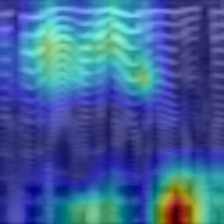

{"timestamp": "2026-04-12T04:59:26.271374+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 92.515, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969966251.png", "band_attr": {"low": 21.025618118927643, "low_mid": 27.2341749752877, "high_mid": 7.342145012069799, "high": 44.39806189371486}}}


--------------------------------------------------------------------------------
Sample: file1000.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.977940 | score_spoof: 0.977940 (thr=0.93)
Band attributions (%): {'low': 21.0256, 'low_mid': 27.2342, 'high_mid': 7.3421, 'high': 44.3981}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969966251.png


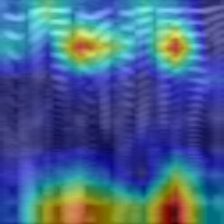

{"timestamp": "2026-04-12T04:59:26.407966+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 91.656, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969966386.png", "band_attr": {"low": 11.292091508128205, "low_mid": 35.30921188212565, "high_mid": 9.87767572213856, "high": 43.521020887607584}}}


--------------------------------------------------------------------------------
Sample: file1001.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.941014 | score_spoof: 0.941014 (thr=0.93)
Band attributions (%): {'low': 11.2921, 'low_mid': 35.3092, 'high_mid': 9.8777, 'high': 43.521}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969966386.png


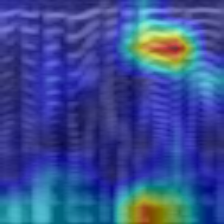

{"timestamp": "2026-04-12T04:59:26.543341+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 90.299, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969966523.png", "band_attr": {"low": 12.986294066344357, "low_mid": 26.45708385247491, "high_mid": 9.432040140883096, "high": 51.12458194029763}}}


--------------------------------------------------------------------------------
Sample: file1004.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: bonafide | confidence: 0.147667 | score_spoof: 0.852333 (thr=0.93)
Band attributions (%): {'low': 12.9863, 'low_mid': 26.4571, 'high_mid': 9.432, 'high': 51.1246}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969966523.png


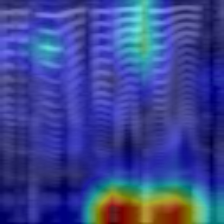

{"timestamp": "2026-04-12T04:59:26.683728+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 96.387, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969966659.png", "band_attr": {"low": 26.389061317835445, "low_mid": 55.96423620142882, "high_mid": 6.732650896110519, "high": 10.91405158462522}}}


--------------------------------------------------------------------------------
Sample: file1005.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.991809 | score_spoof: 0.991809 (thr=0.93)
Band attributions (%): {'low': 26.3891, 'low_mid': 55.9642, 'high_mid': 6.7327, 'high': 10.9141}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969966659.png


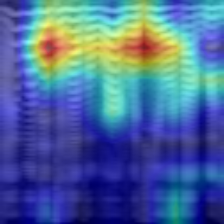

{"timestamp": "2026-04-12T04:59:26.984322+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 208.826, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969966954.png", "band_attr": {"low": 20.732520133839234, "low_mid": 28.17041278047641, "high_mid": 7.001368011934858, "high": 44.09569907374949}}}


--------------------------------------------------------------------------------
Sample: file1010.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.977191 | score_spoof: 0.977191 (thr=0.93)
Band attributions (%): {'low': 20.7325, 'low_mid': 28.1704, 'high_mid': 7.0014, 'high': 44.0957}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969966954.png


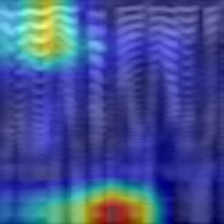

{"timestamp": "2026-04-12T04:59:28.281849+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 96.854, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969968259.png", "band_attr": {"low": 17.558906031292327, "low_mid": 32.187044709063855, "high_mid": 5.597882500022684, "high": 44.65616675962113}}}


--------------------------------------------------------------------------------
Sample: file1018.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.985606 | score_spoof: 0.985606 (thr=0.93)
Band attributions (%): {'low': 17.5589, 'low_mid': 32.187, 'high_mid': 5.5979, 'high': 44.6562}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969968259.png


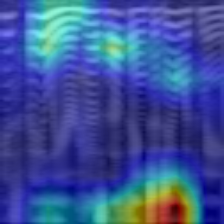

{"timestamp": "2026-04-12T04:59:28.430388+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 96.302, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969968407.png", "band_attr": {"low": 9.659251675722187, "low_mid": 32.29416562298329, "high_mid": 11.5487100997317, "high": 46.49787260156282}}}


--------------------------------------------------------------------------------
Sample: file1019.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.986938 | score_spoof: 0.986938 (thr=0.93)
Band attributions (%): {'low': 9.6593, 'low_mid': 32.2942, 'high_mid': 11.5487, 'high': 46.4979}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969968407.png


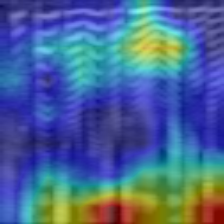

{"timestamp": "2026-04-12T04:59:28.584514+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 104.775, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969968560.png", "band_attr": {"low": 17.61448462912469, "low_mid": 42.47978599440499, "high_mid": 7.064815417125763, "high": 32.84091395934456}}}


--------------------------------------------------------------------------------
Sample: file1021.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.988403 | score_spoof: 0.988403 (thr=0.93)
Band attributions (%): {'low': 17.6145, 'low_mid': 42.4798, 'high_mid': 7.0648, 'high': 32.8409}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969968560.png


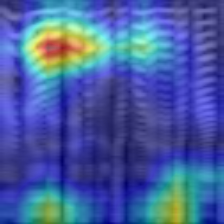

{"timestamp": "2026-04-12T04:59:28.734281+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 94.813, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969968713.png", "band_attr": {"low": 17.157713834512116, "low_mid": 37.094251661796726, "high_mid": 6.649299023013707, "high": 39.09873548067746}}}


--------------------------------------------------------------------------------
Sample: file1029.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.946930 | score_spoof: 0.946930 (thr=0.93)
Band attributions (%): {'low': 17.1577, 'low_mid': 37.0943, 'high_mid': 6.6493, 'high': 39.0987}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969968713.png


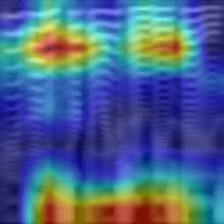

{"timestamp": "2026-04-12T04:59:28.907628+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 119.718, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969968875.png", "band_attr": {"low": 17.541863018879965, "low_mid": 33.77100678891188, "high_mid": 8.899850741718181, "high": 39.78727945048996}}}


--------------------------------------------------------------------------------
Sample: file1038.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.971553 | score_spoof: 0.971553 (thr=0.93)
Band attributions (%): {'low': 17.5419, 'low_mid': 33.771, 'high_mid': 8.8999, 'high': 39.7873}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969968875.png


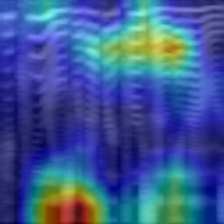

{"timestamp": "2026-04-12T04:59:29.063546+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 96.489, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969969042.png", "band_attr": {"low": 21.774539800749785, "low_mid": 34.45893038801648, "high_mid": 9.461793608523964, "high": 34.30473620270976}}}


--------------------------------------------------------------------------------
Sample: file1040.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.985499 | score_spoof: 0.985499 (thr=0.93)
Band attributions (%): {'low': 21.7745, 'low_mid': 34.4589, 'high_mid': 9.4618, 'high': 34.3047}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969969042.png


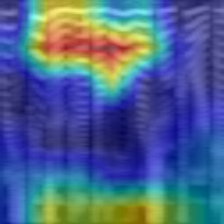

{"timestamp": "2026-04-12T04:59:29.221343+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 104.303, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969969198.png", "band_attr": {"low": 12.212289788933415, "low_mid": 29.36830080088227, "high_mid": 10.889115456238201, "high": 47.53029395394612}}}


--------------------------------------------------------------------------------
Sample: file1045.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.978529 | score_spoof: 0.978529 (thr=0.93)
Band attributions (%): {'low': 12.2123, 'low_mid': 29.3683, 'high_mid': 10.8891, 'high': 47.5303}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969969198.png


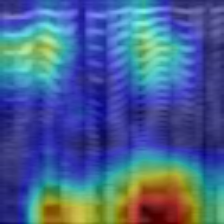

{"timestamp": "2026-04-12T04:59:29.389580+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 109.818, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969969367.png", "band_attr": {"low": 13.62344360930052, "low_mid": 36.96998265151479, "high_mid": 7.56551776559292, "high": 41.841055973591764}}}


--------------------------------------------------------------------------------
Sample: file1046.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.997160 | score_spoof: 0.997160 (thr=0.93)
Band attributions (%): {'low': 13.6234, 'low_mid': 36.97, 'high_mid': 7.5655, 'high': 41.8411}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969969367.png


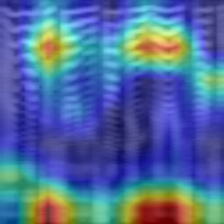

{"timestamp": "2026-04-12T04:59:29.540174+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 99.096, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969969516.png", "band_attr": {"low": 22.460549853567027, "low_mid": 44.450239813065664, "high_mid": 7.9397379533163255, "high": 25.14947238005098}}}


--------------------------------------------------------------------------------
Sample: file1047.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.992148 | score_spoof: 0.992148 (thr=0.93)
Band attributions (%): {'low': 22.4605, 'low_mid': 44.4502, 'high_mid': 7.9397, 'high': 25.1495}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969969516.png


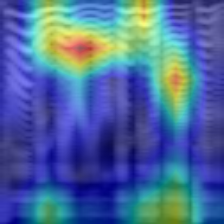

{"timestamp": "2026-04-12T04:59:29.688985+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 99.08, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969969666.png", "band_attr": {"low": 17.310432008766373, "low_mid": 56.98554837451436, "high_mid": 17.67472973679275, "high": 8.029289879926518}}}


--------------------------------------------------------------------------------
Sample: file10.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.219172 | score_spoof: 0.780828 (thr=0.93)
Band attributions (%): {'low': 17.3104, 'low_mid': 56.9855, 'high_mid': 17.6747, 'high': 8.0293}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969969666.png


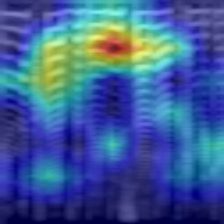

{"timestamp": "2026-04-12T04:59:29.842062+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 108.837, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969969821.png", "band_attr": {"low": 7.319684623922439, "low_mid": 20.498551228078053, "high_mid": 31.295049960069466, "high": 40.886714187930046}}}


--------------------------------------------------------------------------------
Sample: file1006.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.655277 | score_spoof: 0.344723 (thr=0.93)
Band attributions (%): {'low': 7.3197, 'low_mid': 20.4986, 'high_mid': 31.295, 'high': 40.8867}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969969821.png


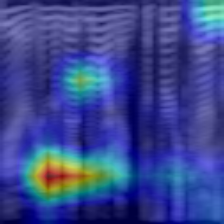

{"timestamp": "2026-04-12T04:59:30.015954+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 127.97, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969969995.png", "band_attr": {"low": 0.14061019433756228, "low_mid": 22.031700684440693, "high_mid": 25.24303124132159, "high": 52.584657879900156}}}


--------------------------------------------------------------------------------
Sample: file1009.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.577019 | score_spoof: 0.422981 (thr=0.93)
Band attributions (%): {'low': 0.1406, 'low_mid': 22.0317, 'high_mid': 25.243, 'high': 52.5847}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969969995.png


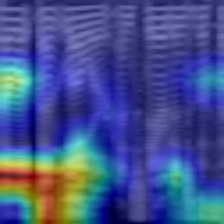

{"timestamp": "2026-04-12T04:59:30.177349+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 111.596, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969970156.png", "band_attr": {"low": 7.466581485755961, "low_mid": 56.22625532420331, "high_mid": 16.402920016345345, "high": 19.904243173695388}}}


--------------------------------------------------------------------------------
Sample: file1010.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.180681 | score_spoof: 0.819319 (thr=0.93)
Band attributions (%): {'low': 7.4666, 'low_mid': 56.2263, 'high_mid': 16.4029, 'high': 19.9042}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969970156.png


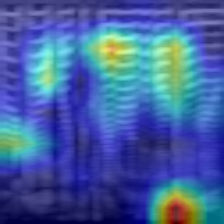

{"timestamp": "2026-04-12T04:59:30.341124+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 114.923, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969970319.png", "band_attr": {"low": 20.87247100379437, "low_mid": 64.0791542959513, "high_mid": 11.495395402276804, "high": 3.5529792979775197}}}


--------------------------------------------------------------------------------
Sample: file1022.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.314340 | score_spoof: 0.685660 (thr=0.93)
Band attributions (%): {'low': 20.8725, 'low_mid': 64.0792, 'high_mid': 11.4954, 'high': 3.553}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969970319.png


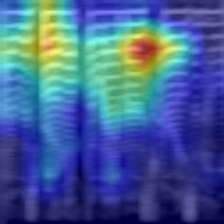

{"timestamp": "2026-04-12T04:59:30.496018+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 103.517, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969970476.png", "band_attr": {"low": 14.594627114324798, "low_mid": 68.13953925070768, "high_mid": 9.106139331658, "high": 8.159694303309523}}}


--------------------------------------------------------------------------------
Sample: file1031.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.207475 | score_spoof: 0.792525 (thr=0.93)
Band attributions (%): {'low': 14.5946, 'low_mid': 68.1395, 'high_mid': 9.1061, 'high': 8.1597}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969970476.png


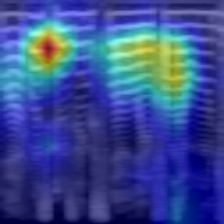

{"timestamp": "2026-04-12T04:59:30.649575+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 104.938, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969970628.png", "band_attr": {"low": 0.8753498481116583, "low_mid": 33.42621868287738, "high_mid": 40.627455952866384, "high": 25.07097551614458}}}


--------------------------------------------------------------------------------
Sample: file1032.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.801524 | score_spoof: 0.198476 (thr=0.93)
Band attributions (%): {'low': 0.8753, 'low_mid': 33.4262, 'high_mid': 40.6275, 'high': 25.071}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969970628.png


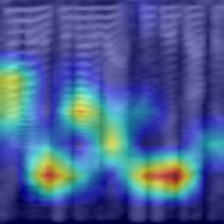

{"timestamp": "2026-04-12T04:59:30.806139+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 110.949, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969970782.png", "band_attr": {"low": 14.364573689358293, "low_mid": 27.716385724411165, "high_mid": 25.16166312036826, "high": 32.757377465862284}}}


--------------------------------------------------------------------------------
Sample: file1039.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: spoof | confidence: 0.992044 | score_spoof: 0.992044 (thr=0.93)
Band attributions (%): {'low': 14.3646, 'low_mid': 27.7164, 'high_mid': 25.1617, 'high': 32.7574}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969970782.png


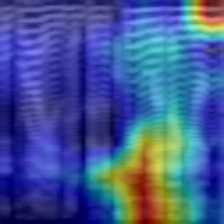

{"timestamp": "2026-04-12T04:59:30.969775+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 110.379, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969970949.png", "band_attr": {"low": 10.157292518931904, "low_mid": 53.520094954563746, "high_mid": 19.799071276313203, "high": 16.523541250191155}}}


--------------------------------------------------------------------------------
Sample: file1044.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.171844 | score_spoof: 0.828156 (thr=0.93)
Band attributions (%): {'low': 10.1573, 'low_mid': 53.5201, 'high_mid': 19.7991, 'high': 16.5235}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969970949.png


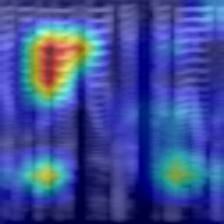

{"timestamp": "2026-04-12T04:59:31.147105+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 123.573, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969971124.png", "band_attr": {"low": 4.09713355025834, "low_mid": 42.468099429817975, "high_mid": 26.762576436918607, "high": 26.67219058300508}}}


--------------------------------------------------------------------------------
Sample: file1059.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.333223 | score_spoof: 0.666777 (thr=0.93)
Band attributions (%): {'low': 4.0971, 'low_mid': 42.4681, 'high_mid': 26.7626, 'high': 26.6722}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969971124.png


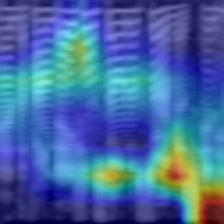

{"timestamp": "2026-04-12T04:59:31.321622+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 118.798, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969971301.png", "band_attr": {"low": 29.342213872312367, "low_mid": 55.063126408845676, "high_mid": 8.97432187852252, "high": 6.620337840319444}}}


--------------------------------------------------------------------------------
Sample: file1068.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.267312 | score_spoof: 0.732688 (thr=0.93)
Band attributions (%): {'low': 29.3422, 'low_mid': 55.0631, 'high_mid': 8.9743, 'high': 6.6203}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969971301.png


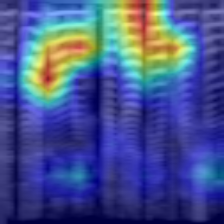

{"timestamp": "2026-04-12T04:59:31.488179+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 118.805, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969971465.png", "band_attr": {"low": 19.164764722864437, "low_mid": 42.20424141299785, "high_mid": 12.829918268829907, "high": 25.80107559530781}}}


--------------------------------------------------------------------------------
Sample: file1074.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.103828 | score_spoof: 0.896172 (thr=0.93)
Band attributions (%): {'low': 19.1648, 'low_mid': 42.2042, 'high_mid': 12.8299, 'high': 25.8011}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969971465.png


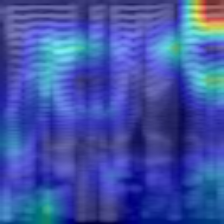

{"timestamp": "2026-04-12T04:59:31.654775+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 116.445, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969971632.png", "band_attr": {"low": 5.806980936172502, "low_mid": 38.009218938033825, "high_mid": 27.222443891333747, "high": 28.961356234459924}}}


--------------------------------------------------------------------------------
Sample: file1075.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.150620 | score_spoof: 0.849380 (thr=0.93)
Band attributions (%): {'low': 5.807, 'low_mid': 38.0092, 'high_mid': 27.2224, 'high': 28.9614}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969971632.png


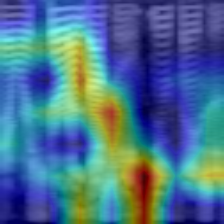

{"timestamp": "2026-04-12T04:59:31.819557+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 115.268, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969971798.png", "band_attr": {"low": 14.860758713075551, "low_mid": 65.13655639761649, "high_mid": 15.92290857750508, "high": 4.079776311802889}}}


--------------------------------------------------------------------------------
Sample: file1080.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.413631 | score_spoof: 0.586369 (thr=0.93)
Band attributions (%): {'low': 14.8608, 'low_mid': 65.1366, 'high_mid': 15.9229, 'high': 4.0798}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969971798.png


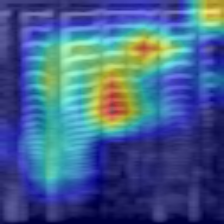

{"timestamp": "2026-04-12T04:59:31.993610+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 111.828, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969971972.png", "band_attr": {"low": 10.07971657899822, "low_mid": 74.60426203683767, "high_mid": 12.744299444488652, "high": 2.5717219396754625}}}


--------------------------------------------------------------------------------
Sample: file1083.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.692732 | score_spoof: 0.307268 (thr=0.93)
Band attributions (%): {'low': 10.0797, 'low_mid': 74.6043, 'high_mid': 12.7443, 'high': 2.5717}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775969971972.png


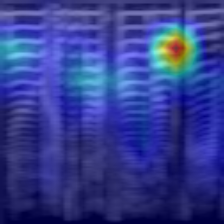

Summary (30 samples, threshold=0.93):
1. ✅ file100.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt | exp=spoof pred=spoof score_spoof=0.9725
2. ✅ file1000.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt | exp=spoof pred=spoof score_spoof=0.9779
3. ✅ file1001.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt | exp=spoof pred=spoof score_spoof=0.9410
4. ❌ file1004.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt | exp=spoof pred=bonafide score_spoof=0.8523
5. ✅ file1005.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt | exp=spoof pred=spoof score_spoof=0.9918
6. ✅ file1010.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt | exp=spoof pred=spoof score_spoof=0.9772
7. ✅ file1018.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt | exp=spoof pred=spoof score_spoof=0.9856
8. ✅ file1019.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt | exp=spoof pred=spoof score_spoof=0.9869
9. ✅ file1021.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt | exp=spoof pred=spoof score_spoof=0.9884
10. ✅ 

In [14]:
# Grad-CAM mini-batch check: 15 spoof + 15 bonafide
from pathlib import Path
import torch
import torch.nn.functional as F
import yaml
from IPython.display import display
from PIL import Image

from src.cv.gradcam import run_gradcam

cfg = yaml.safe_load(Path("config.yaml").read_text())
pre_root = Path(cfg["training"]["preprocessed_root"]) / "test"
threshold = float(cfg["model"].get("decision_threshold", 0.5))

spoof_files = sorted((pre_root / "spoof").glob("*.pt"))
bonafide_files = sorted((pre_root / "bonafide").glob("*.pt"))

assert len(spoof_files) >= 2, f"Need >=2 spoof .pt files in {(pre_root / 'spoof')}"
assert len(bonafide_files) >= 2, f"Need >=2 bonafide .pt files in {(pre_root / 'bonafide')}"

selected = [("spoof", p) for p in spoof_files[:15]] + [("bonafide", p) for p in bonafide_files[:15]]
labels = ("bonafide", "spoof")

results = []

for expected_label, pt_path in selected:
    tensor = torch.load(pt_path, map_location="cpu")
    if tensor.ndim == 4:
        tensor = tensor.squeeze(0)

    x = tensor.to(device=device, dtype=torch.float32)
    if x.ndim == 3:
        x = x.unsqueeze(0)

    with torch.no_grad():
        logits = model(x)
        score_spoof = float(torch.sigmoid(logits[:, 1]).item())

    pred_label = "spoof" if score_spoof >= threshold else "bonafide"
    confidence = score_spoof if pred_label == "spoof" else (1.0 - score_spoof)

    heatmap_path, band_attr = run_gradcam(tensor=x, model=model, cfg=cfg)

    row = {
        "expected": expected_label,
        "sample": pt_path.name,
        "pred": pred_label,
        "confidence": confidence,
        "score_spoof": score_spoof,
        "threshold": threshold,
        "band_attr": band_attr,
        "heatmap": str(heatmap_path),
    }
    results.append(row)

    print("-" * 80)
    print("Sample:", row["sample"])
    print("Expected:", row["expected"])
    print(f"Predicted: {row['pred']} | confidence: {row['confidence']:.6f} | score_spoof: {row['score_spoof']:.6f} (thr={threshold})")
    print("Band attributions (%):", {k: round(v, 4) for k, v in row["band_attr"].items()})
    print("Heatmap:", row["heatmap"])
    display(Image.open(row["heatmap"]))

print("=" * 80)
print(f"Summary ({len(results)} samples, threshold={threshold}):")
for i, r in enumerate(results, start=1):
    mark = "✅" if r["expected"] == r["pred"] else "❌"
    print(f"{i}. {mark} {r['sample']} | exp={r['expected']} pred={r['pred']} score_spoof={r['score_spoof']:.4f}")

## Threshold Tuning and Decision Calibration (Validation Set)

In [15]:
from pathlib import Path
import csv
import numpy as np
import torch
import yaml

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)

from IPython.display import Markdown, display

assert "model" in globals() and "device" in globals(), "Jalankan Cell 8 dulu (load checkpoint)"

cfg = yaml.safe_load(Path("config.yaml").read_text())
pre_root = Path(cfg["training"]["preprocessed_root"])

# Pilih split validasi. Kalau folder `validation` tidak ada, coba `val`.
val_split = "validation"
val_root = pre_root / val_split
if not (val_root / "bonafide").exists():
    alt = "val"
    alt_root = pre_root / alt
    if (alt_root / "bonafide").exists():
        val_split = alt
        val_root = alt_root
    else:
        raise FileNotFoundError(f"Tidak menemukan validation set di bawah: {pre_root}. Coba pastikan ada `{val_split}` / `val`")

threshold_default = float(cfg["model"].get("decision_threshold", 0.5))
# Risiko produk: batasi salah bonafide menjadi spoof. (FPR = FP/(FP+TN))
target_fpr_bonafide = float(cfg.get("acceptance_criteria", {}).get("target_eer", 0.10))

BATCH_SIZE = int(cfg["training"].get("batch_size", 16))

def _load_pt(path: Path) -> torch.Tensor:
    t = torch.load(path, map_location="cpu")
    if t.ndim == 4:
        t = t.squeeze(0)
    return t.to(dtype=torch.float32)

items = []

EVAL_MAX_FILES = None
for label_name, y in (("bonafide", 0), ("spoof", 1)):
    d = val_root / label_name
    if not d.is_dir():
        raise FileNotFoundError(f"Folder tidak ada: {d}")
    for p in sorted(d.glob("*.pt")):
        items.append((p, y))

if EVAL_MAX_FILES is not None:
    items = items[: int(EVAL_MAX_FILES)]

n_b = sum(1 for _, y in items if y == 0)
n_s = sum(1 for _, y in items if y == 1)
if len(items) == 0:
    raise RuntimeError(f"Tidak ada file .pt di bawah {val_root}")

display(Markdown(f"**Threshold tuning — validation**\n"
                 f"Folder: `{val_root}`\n"
                 f"Total: {len(items)} (bonafide={n_b}, spoof={n_s})\n"
                 f"Default threshold: {threshold_default}\n"
                 f"Target FPR bonafide: {target_fpr_bonafide}"))

y_true = []
y_scores = []

n_batches = (len(items) + BATCH_SIZE - 1) // BATCH_SIZE
for bi in range(n_batches):
    chunk = items[bi * BATCH_SIZE : (bi + 1) * BATCH_SIZE]
    batch = torch.stack([_load_pt(p) for p, _ in chunk]).to(device)
    with torch.no_grad():
        logits = model(batch)
    scores = torch.sigmoid(logits[:, 1]).detach().cpu().numpy()

    for j, (_, y) in enumerate(chunk):
        y_true.append(y)
        y_scores.append(float(scores[j]))

y_true_arr = np.asarray(y_true, dtype=np.int64)
y_scores_arr = np.asarray(y_scores, dtype=np.float64)

# ROC-based selection
fpr, tpr, thresholds = roc_curve(y_true_arr, y_scores_arr, pos_label=1)
auc = float(roc_auc_score(y_true_arr, y_scores_arr))

fnr = 1.0 - tpr
idx_eer = int(np.nanargmin(np.abs(fnr - fpr)))
threshold_eer = float(thresholds[idx_eer])
eer_est = float((fnr[idx_eer] + fpr[idx_eer]) / 2.0)

valid = np.where(fpr <= target_fpr_bonafide)[0]
if valid.size > 0:
    idx_risk = int(valid[np.nanargmax(tpr[valid])])
else:
    # kalau tidak ada threshold yang memenuhi constraint, fallback ke threshold EER
    idx_risk = idx_eer

threshold_risk = float(thresholds[idx_risk])
spoof_recall_risk = float(tpr[idx_risk])
fpr_risk = float(fpr[idx_risk])

def _report(thr: float, name: str):
    y_pred = (y_scores_arr >= thr).astype(np.int64)
    cm = confusion_matrix(y_true_arr, y_pred, labels=[0, 1])
    # For label=1 (spoof): recall = TP/(TP+FN) = TPR
    tp = int(cm[1, 1])
    fn = int(cm[1, 0])
    fp = int(cm[0, 1])
    tn = int(cm[0, 0])
    recall_spoof = tp / max(1, tp + fn)
    fpr_bonafide = fp / max(1, fp + tn)
    print("\n---", name, "---")
    print(f"Threshold: {thr:.6f}")
    print(f"AUC-ROC (global): {auc:.6f}")
    print(f"Spoof recall (TPR): {recall_spoof:.6f}")
    print(f"Bonafide FPR: {fpr_bonafide:.6f}")
    print("Confusion matrix (rows=true [bonafide, spoof], cols=pred [bonafide, spoof]):")
    print(cm)
    print(classification_report(y_true_arr, y_pred, labels=[0, 1], target_names=["bonafide", "spoof"], digits=4, zero_division=0))

print("\n### ROC summary (validation) ###")
print(f"AUC-ROC: {auc:.6f}")
print(f"EER threshold: {threshold_eer:.6f} (EER est={eer_est:.6f})")
print(f"Risk threshold (FPR bonafide <= {target_fpr_bonafide}): {threshold_risk:.6f}")

_report(threshold_default, "Default threshold (cfg)")
_report(threshold_eer, "Threshold EER-min")
_report(threshold_risk, "Threshold risk-aware")

SWEEP_THR_MIN = max(0.10, threshold_eer - 0.15)
SWEEP_THR_MAX = 0.99
SWEEP_N = 50

print("\n### Sweep threshold (validation):", SWEEP_THR_MIN, "–", SWEEP_THR_MAX, "###")
hdr = ("thr", "acc", "rec_spoof", "rec_bon", "fpr_bon", "f1_macro")
print("\t".join(hdr))
sweep_rows = []
for thr in np.linspace(SWEEP_THR_MIN, SWEEP_THR_MAX, SWEEP_N):
    y_pred = (y_scores_arr >= thr).astype(np.int64)
    cm = confusion_matrix(y_true_arr, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    n = tp + tn + fp + fn
    acc = (tp + tn) / max(1, n)
    recall_spoof = tp / max(1, tp + fn)
    recall_bon = tn / max(1, tn + fp)
    fpr_bon = fp / max(1, fp + tn)
    f1m = float(f1_score(y_true_arr, y_pred, average="macro", zero_division=0))
    sweep_rows.append((float(thr), acc, recall_spoof, recall_bon, fpr_bon, f1m))
    print(
        f"{thr:.4f}\t{acc:.4f}\t{recall_spoof:.4f}\t{recall_bon:.4f}\t{fpr_bon:.4f}\t{f1m:.4f}"
    )

csv_sweep = val_root / "threshold_sweep_validation.csv"
with csv_sweep.open("w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["threshold", "accuracy", "recall_spoof", "recall_bonafide", "fpr_bonafide", "f1_macro"])
    for row in sweep_rows:
        w.writerow([f"{row[0]:.6f}"] + [f"{x:.6f}" for x in row[1:]])
print(f"\nCSV sweep tersimpan: {csv_sweep}")


**Threshold tuning — validation**
Folder: `/content/drive/MyDrive/dsdba-fix/preprocessed/validation`
Total: 2826 (bonafide=1413, spoof=1413)
Default threshold: 0.93
Target FPR bonafide: 0.1


### ROC summary (validation) ###
AUC-ROC: 0.974428
EER threshold: 0.969121 (EER est=0.092711)
Risk threshold (FPR bonafide <= 0.1): 0.967393

--- Default threshold (cfg) ---
Threshold: 0.930000
AUC-ROC (global): 0.974428
Spoof recall (TPR): 0.981599
Bonafide FPR: 0.230715
Confusion matrix (rows=true [bonafide, spoof], cols=pred [bonafide, spoof]):
[[1087  326]
 [  26 1387]]
              precision    recall  f1-score   support

    bonafide     0.9766    0.7693    0.8606      1413
       spoof     0.8097    0.9816    0.8874      1413

    accuracy                         0.8754      2826
   macro avg     0.8932    0.8754    0.8740      2826
weighted avg     0.8932    0.8754    0.8740      2826


--- Threshold EER-min ---
Threshold: 0.969121
AUC-ROC (global): 0.974428
Spoof recall (TPR): 0.907289
Bonafide FPR: 0.092711
Confusion matrix (rows=true [bonafide, spoof], cols=pred [bonafide, spoof]):
[[1282  131]
 [ 131 1282]]
              precision    recall  f1-score   support

    bonafi

In [ ]:
# import random
# import numpy as np
# import torch

# SEED = 42

# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# torch.cuda.manual_seed_all(SEED)

# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

# try:
#     torch.use_deterministic_algorithms(True)
# except Exception as e:
#     print("Deterministic algorithms not fully enabled:", e)

# print("Seeds set:", SEED)

In [ ]:
# import torch
# import onnxruntime as ort
# import numpy as np

# # Test manual
# dummy = torch.randn(1, 3, 224, 224)

# # Output PyTorch
# model_cpu.eval()
# with torch.no_grad():
#     pt_out = model_cpu(dummy).numpy()

# # Output ONNX
# session = ort.InferenceSession(str(onnx_path), providers=['CPUExecutionProvider'])
# onnx_out = session.run(None, {'input': dummy.numpy()})[0]

# diff = np.abs(pt_out - onnx_out).max()
# print(f'Max difference: {diff}')
# print(f'PyTorch output: {pt_out}')
# print(f'ONNX output: {onnx_out}')